In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from os.path import join as pjoin
import re
import os
from utils import OperonArgs

In [47]:
ini_file = 'conf/iob_0.ini'

args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')
fname_train_id = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_galaxy_ids_los.txt')
fname_val_id = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_val_galaxy_ids_los.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,:-1]
y = data[:,-1]
train_id, train_los = np.loadtxt(fname_train_id, dtype=float, unpack=True, skiprows=1)


Reading from configuration file: conf/iob_0.ini


(46000, 9) (46000,)
['IOB1', 'IOB2', 'IOB3', 'IOB4', 'IOB5', 'IOB6', 'IOB7', 'IOB8', 'lam', 'A']
46
0.1203
0.2771
46 27


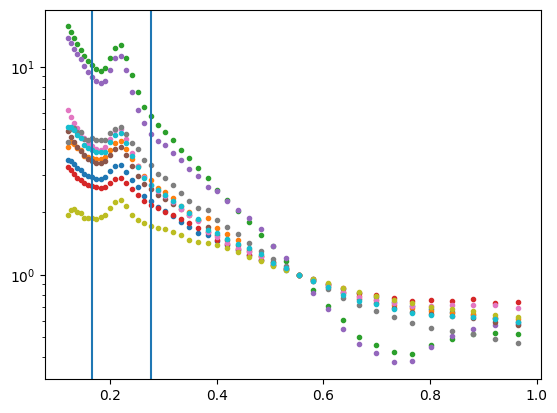

In [48]:
print(X.shape, y.shape)
print(names)
lam = X[:,names.index('lam')]

nlam = len(np.unique(lam))
print(nlam)
for i in range(10):
    plt.semilogy(lam[i*nlam:(i+1)*nlam]*args.lambda_V, y[i*nlam:(i+1)*nlam], '.')
plt.axvline(0.3*args.lambda_V)
plt.axvline(0.5*args.lambda_V)

print(lam.min() * args.lambda_V)
print(0.5 * args.lambda_V)

lam_dimful = lam * args.lambda_V
lam_min = 0.5 * args.lambda_V
lam_min = 0.28
lam_uniq = np.unique(lam_dimful)
print(len(lam_uniq), len(lam_uniq[lam_uniq > lam_min]))


Reading from configuration file: conf/iob_10.ini
(69000, 9) (69000,)
['IOB1', 'IOB2', 'IOB3', 'IOB4', 'IOB5', 'IOB6', 'IOB7', 'IOB8', 'lam', 'A']
46


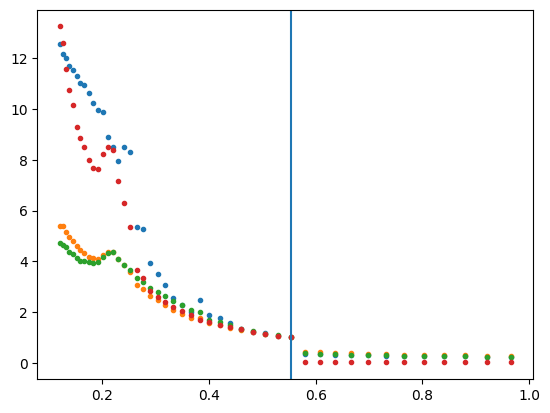

In [56]:
ini_file = 'conf/iob_10.ini'

args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')
fname_train_id = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_galaxy_ids_los.txt')
fname_val_id = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_val_galaxy_ids_los.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,:-1]
y = data[:,-1]
train_id, train_los = np.loadtxt(fname_train_id, dtype=float, unpack=True, skiprows=1)

print(X.shape, y.shape)
print(names)
lam = X[:,names.index('lam')]

nlam = len(np.unique(lam))
print(nlam)
# for i in range(10):
for i in range(4):
    plt.plot(lam[i*nlam:(i+1)*nlam]*args.lambda_V, y[i*nlam:(i+1)*nlam], '.')
plt.axvline(args.lambda_V)


Reading from configuration file: conf/iob_17.ini

Splitting data into training, validation, and test sets...
	File: ../data/gal_los_iobcomp_attcurve_galprop.dat
   galaxy_id   los      IOB1      IOB2      IOB3      IOB4      IOB5  \
0   524576.0  28.0 -0.057096  0.004003 -0.001398  0.001051 -0.000840   
1   683079.0  39.0  0.016162  0.014319 -0.011058 -0.005481 -0.001857   
2   419176.0  18.0  0.147944 -0.031180 -0.043807  0.024374 -0.028433   
3   533793.0   1.0 -0.046068 -0.001357  0.002156 -0.003055  0.000878   
4   418505.0  16.0  0.009780  0.023803 -0.017321 -0.007356 -0.005911   

       IOB6      IOB7      IOB8  ...  logMstar [Msun]  logMgas [Msun]  \
0  0.000889  0.001335 -0.001133  ...        10.303802       10.714520   
1 -0.006859 -0.000036 -0.001860  ...         9.138786       10.061392   
2 -0.022356 -0.001905 -0.003123  ...         9.722306       10.031602   
3 -0.000120  0.000846 -0.001181  ...        10.185971       10.673258   
4 -0.006574  0.000155 -0.001911  ...    

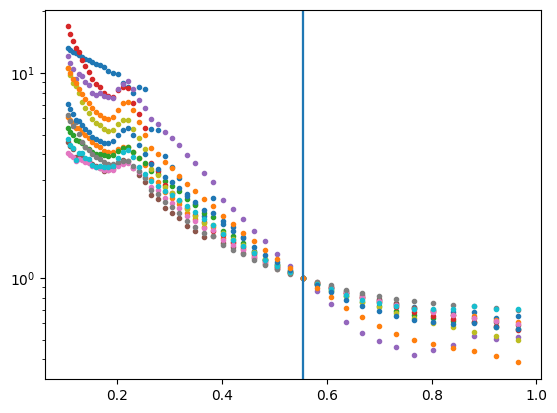

In [50]:
ini_file = 'conf/iob_17.ini'

args = OperonArgs(ini_file)

print('\nSplitting data into training, validation, and test sets...')
print('\tFile:', args.input_file)

# Read all galaxy data
data = pd.read_csv(args.input_file, sep='\t',)
print(data.head())

# Get attenuation column names
to_norm = False
if f'logA_{int(args.lambda_V*1e4)}A' in data.keys():
    attenuation_cols = [col for col in data.columns if re.match(r'logA_\d+A', col)]
    if not np.all(data[f'logA_{int(args.lambda_V*1e4)}A'] == 0):
        print('\tWarning: logA_V column is not all zeros: normalising data')
        to_norm = True
        # for col in attenuation_cols:
        #     data[col] = data[col] - data[f'logA_{int(args.lambda_V*1e4)}A']
        # assert np.all(data[f'logA_{int(args.lambda_V*1e4)}A'] == 0), "Normalisation failed"
elif f'A_{int(args.lambda_V*1e4)}A' in data.keys():
    attenuation_cols = [col for col in data.columns if re.match(r'A_\d+A', col)]
    if not np.all(data[f'A_{int(args.lambda_V*1e4)}A'] == 1):
        print('\tWarning: A_V column is not all ones: normalising data')
        to_norm = True
        # for col in attenuation_cols:
            # data[col] = data[col] / data[f'A_{int(args.lambda_V*1e4)}A']
        # assert np.all(data[f'A_{int(args.lambda_V*1e4)}A'] == 1), "Normalisation failed"
else:
    raise ValueError("Column with lambda_V not found in input file")


# Extract the wavelength in angstroms
# Mask these to range [lam_min, lam_max]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
sort_idx = np.argsort(lam_arr)
lam_arr = lam_arr[sort_idx]
mask = (lam_arr < args.lam_max) & (lam_arr > args.lam_min)
lam_arr = lam_arr[mask]
attenuation_cols = [attenuation_cols[i] for i in sort_idx if mask[i]]
print('\tWavelengths:', lam_arr)
print(attenuation_cols)
lam_arr = lam_arr / args.lambda_V

# Get all galaxy ids
galaxy_ids = data['galaxy_id'].unique()
print('\tNumber of unique galaxies:', len(galaxy_ids), 'of', len(data), 'attenuation curves')

# Estimate number of unique IDs needed
ntrain = int(args.ntrain / (args.ntrain + args.nval + args.ntest) * len(galaxy_ids))
nval= int(args.nval / (args.ntrain + args.nval + args.ntest) * len(galaxy_ids))
ntest = len(galaxy_ids) - nval - ntrain
print(f'\tNumber of galaxies for training: {ntrain}, validation: {nval}, test: {ntest}')

# Shuffle the galaxy ids and split into training, validation, and test sets
np.random.seed(args.seed)
np.random.shuffle(galaxy_ids)
train_ids = galaxy_ids[:ntrain]
val_ids = galaxy_ids[ntrain:ntrain+nval]
test_ids = galaxy_ids[ntrain+nval:ntrain+nval+ntest]

# Split data
m = np.isin(data['galaxy_id'], train_ids)
train_data = data[m]
m = np.isin(data['galaxy_id'], val_ids)
val_data = data[m]
m = np.isin(data['galaxy_id'], test_ids)
test_data = data[m]

print('\tOriginal training data shape:', train_data.shape)
print('\tOriginal validation data shape:', val_data.shape)
print('\tOriginal test data shape:', test_data.shape)

# Each galaxy can have more than one los, so we have too many points now
# We again shuffle the data and reduce the number of objects
train_data = train_data.iloc[np.random.permutation(train_data.shape[0])[:args.ntrain],:]
val_data = val_data.iloc[np.random.permutation(val_data.shape[0])[:args.nval], :]
test_data = test_data.iloc[np.random.permutation(test_data.shape[0])[:args.ntest], :]

print('\tNumber of training curves:', train_data.shape[0])
print('\tNumber of validation curves:', val_data.shape[0])
print('\tNumber of test curves:', test_data.shape[0])

print('Train data')
print(train_data.keys())

# Get cols beginning with in_param and the rest is an integer
in_cols = [col for col in data.columns if col.startswith(args.in_param.upper()) and col[len(args.in_param):].isdigit()]
in_cols.sort()
print(f'\tNumber of input parameters found: {len(in_cols)}')
in_cols = in_cols[:args.npar]
print(f'\tNumber of inputparameters used: {len(in_cols)}')

# Make output directory
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
os.makedirs(dirname, exist_ok=True)

for name, data_set in zip(['train', 'val', 'test'], [train_data, val_data, test_data]):
# for name, data_set in zip(['train'], [train_data, val_data, test_data]):
    ngal = len(data_set)
    nlam = len(lam_arr)
    print(f'\nProcessing {name} data with {ngal} galaxies and {nlam} wavelengths...')
    properties = data_set[in_cols].values
    props_repeated = np.repeat(properties, nlam, axis=0)
    wavelengths_tiled = np.tile(lam_arr, ngal).reshape(-1, 1)
    curves_flat = data_set[attenuation_cols].values.reshape(-1, 1)

    if to_norm:
        print('\tNormalising data...')
        if f'logA_{int(args.lambda_V*1e4)}A' in data_set.keys():
            curves_flat = curves_flat - np.repeat(data_set[f'logA_{int(args.lambda_V*1e4)}A'].values, nlam).reshape(-1, 1)
        elif f'A_{int(args.lambda_V*1e4)}A' in data_set.keys():
            curves_flat = curves_flat / np.repeat(data_set[f'A_{int(args.lambda_V*1e4)}A'].values, nlam).reshape(-1, 1)

    print(wavelengths_tiled.shape, curves_flat.shape)
    nlam = len(np.unique(wavelengths_tiled))
    print(f'\tNumber of wavelengths after masking: {nlam}')
    for i in range(4):
        plt.semilogy(wavelengths_tiled[i*nlam:(i+1)*nlam]*args.lambda_V, curves_flat[i*nlam:(i+1)*nlam], '.')
    plt.axvline(args.lambda_V)

    output_array = np.hstack((props_repeated, wavelengths_tiled, curves_flat))
    print(f'Saving {name.capitalize()} data of shape {output_array.shape} to {dirname} ...')

    header = ' '.join(in_cols + ['lam', 'A'])
    outname = pjoin(dirname, f'{args.in_param}_{name}_data.txt')
    # np.savetxt(outname, output_array, header=header, comments='')

    # Now save the galaxy ids and los in case we need them later
    output_array = data_set[['galaxy_id', 'los']].values
    outname = pjoin(dirname, f'{args.in_param}_{name}_galaxy_ids_los.txt')
    # np.savetxt(outname, output_array, fmt='%d', header='\t'.join(['galaxy_id', 'los']), delimiter='\t')